# Raw SVI diagnostics

Fit one Raw SVI slice per expiry to the screened SPX midpoint-IV panel, then project total variance onto a calendar-monotone grid without refitting the slices. This notebook summarizes calibration, compares raw and repaired smiles/surfaces, and checks residuals, held-out strikes, stability, butterfly conditions, and calendar monotonicity. The checks are diagnostics; sampled grids do not prove absence of arbitrage.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go

ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.raw_svi import (
    fit_raw_svi_surface,
    raw_svi_butterfly_diagnostic,
    raw_svi_total_variance,
)
from src.vol_surface import (
    build_total_variance_grid,
    enforce_calendar_monotonicity,
    evaluate_surface,
)

PANEL_PATH = ROOT / 'data/processed/spx_iv_panel_2025-08-29.csv'
panel = pd.read_csv(PANEL_PATH, parse_dates=['quote_date', 'expiry_date'])
unconstrained_result = fit_raw_svi_surface(panel)
arbitrage_aware_result = fit_raw_svi_surface(panel, enforce_arbitrage=True)
observations = arbitrage_aware_result['observations'].copy()
parameters = arbitrage_aware_result['parameters_by_expiry'].copy()
calendar_k_grid = np.linspace(-0.5, 0.25, 151)
surface_grid = build_total_variance_grid(parameters, calendar_k_grid)
surface_grid['repaired_total_variance'] = enforce_calendar_monotonicity(
    surface_grid['raw_total_variance']
)
observations['days_to_expiry'] = (observations['expiry_date'] - observations['quote_date']).dt.days
observations['fitted_iv'] = np.sqrt(observations['fitted_w'] / observations['time_to_expiry'])
observations['iv_residual'] = observations['fitted_iv'] - observations['mid_iv']
print(f'Input panel: {len(panel):,} rows; fitted OTM quotes: {len(observations):,}; expiries: {len(parameters)}')
print(f'Arbitrage-aware calibration: {arbitrage_aware_result["arbitrage_constrained"]}')

Input panel: 14,852 rows; fitted OTM quotes: 6,550; expiries: 38
Arbitrage-aware calibration: True


## Fit summary

Each expiry is calibrated independently by least squares in total variance, $w=\sigma^2\tau$. The table below reports the arbitrage-aware Raw SVI parameters, in-sample RMSE, and number of feasible calibration starts. The separate comparison shows the fit-cost of imposing the sampled butterfly conditions.

In [2]:
fit_summary = parameters.merge(
    observations.groupby('expiry_date').agg(
        days_to_expiry=('days_to_expiry', 'first'),
        n_quotes=('market_w', 'size'),
        k_min=('log_moneyness', 'min'),
        k_max=('log_moneyness', 'max'),
    ).reset_index(),
    on='expiry_date',
)
fit_summary = fit_summary[['expiry_date', 'days_to_expiry', 'n_quotes', 'a', 'b', 'rho', 'm', 'sigma', 'rmse', 'feasible_starts', 'k_min', 'k_max']]
display(fit_summary.assign(expiry_date=fit_summary['expiry_date'].dt.strftime('%Y-%m-%d')).round(6))
display(fit_summary[['n_quotes', 'rmse']].describe().round(6))

unconstrained_rmse = unconstrained_result['parameters_by_expiry'][['expiry_date', 'rmse']].rename(columns={'rmse': 'unconstrained_rmse'})
arbitrage_rmse = parameters[['expiry_date', 'rmse']].rename(columns={'rmse': 'arbitrage_aware_rmse'})
rmse_comparison = unconstrained_rmse.merge(arbitrage_rmse, on='expiry_date', validate='one_to_one')
rmse_comparison['rmse_increase'] = rmse_comparison['arbitrage_aware_rmse'] - rmse_comparison['unconstrained_rmse']
display(rmse_comparison.assign(expiry_date=rmse_comparison['expiry_date'].dt.strftime('%Y-%m-%d')).round(7))
display(rmse_comparison[['unconstrained_rmse', 'arbitrage_aware_rmse', 'rmse_increase']].mean().to_frame('mean_rmse').round(7))

,expiry_date,days_to_expiry,n_quotes,a,b,rho,m,sigma,rmse,feasible_starts,k_min,k_max
0,2025-09-02,4,112,-0.000282,0.010653,-0.650387,-0.023065,0.038354,0.000006,2,-0.094888,0.012343
1,2025-09-03,5,126,-0.000525,0.014918,-0.707687,-0.034515,0.054081,0.000006,2,-0.160975,0.016029
2,2025-09-04,6,133,-0.000682,0.017328,-0.749342,-0.043255,0.064835,0.000012,1,-0.179335,0.019820
3,2025-09-05,7,188,-0.001865,0.024203,-0.638365,-0.055407,0.106942,0.000024,1,-0.256562,0.027864
4,2025-09-08,10,138,-0.000760,0.020532,-0.877855,-0.063349,0.083448,0.000018,1,-0.236873,0.028503
5,2025-09-09,11,139,-0.001809,0.026512,-0.752549,-0.066540,0.111066,0.000025,1,-0.297553,0.032201
6,2025-09-10,12,141,-0.004400,0.035038,-0.538705,-0.055338,0.155469,0.000031,1,-0.340247,0.035804
7,2025-09-11,13,140,-0.001687,0.028520,-0.825318,-0.070605,0.112360,0.000017,1,-0.297809,0.043117
8,2025-09-12,14,185,-0.002354,0.031128,-0.733394,-0.062942,0.122087,0.000025,1,-0.385134,0.047238
9,2025-09-15,17,124,-0.004850,0.038593,-0.571728,-0.053266,0.161386,0.000033,1,-0.431620,0.042838


,n_quotes,rmse
count,38.000000,38.000000
mean,172.368421,0.000221
std,108.502440,0.000287
min,52.000000,0.000006
25%,106.750000,0.000032
50%,130.000000,0.000095
75%,187.250000,0.000229
max,472.000000,0.001210


,expiry_date,unconstrained_rmse,arbitrage_aware_rmse,rmse_increase
0,2025-09-02,0.000005,0.000006,1.000000e-06
1,2025-09-03,0.000006,0.000006,2.000000e-07
2,2025-09-04,0.000012,0.000012,0.000000e+00
3,2025-09-05,0.000024,0.000024,0.000000e+00
4,2025-09-08,0.000018,0.000018,0.000000e+00
5,2025-09-09,0.000025,0.000025,0.000000e+00
6,2025-09-10,0.000030,0.000030,0.000000e+00
7,2025-09-11,0.000017,0.000017,0.000000e+00
8,2025-09-12,0.000025,0.000025,0.000000e+00
9,2025-09-15,0.000033,0.000033,0.000000e+00


,mean_rmse
unconstrained_rmse,0.000127
arbitrage_aware_rmse,0.000220
rmse_increase,0.000093


## Representative 2D smiles

Select the available expiries nearest 7, 30, 90, and 300 DTE. Points are screened market observations; each line is that expiry's fitted Raw SVI total variance curve. The line is shown only over the observed $k$ range, so this view does not disguise extrapolation as market fit.

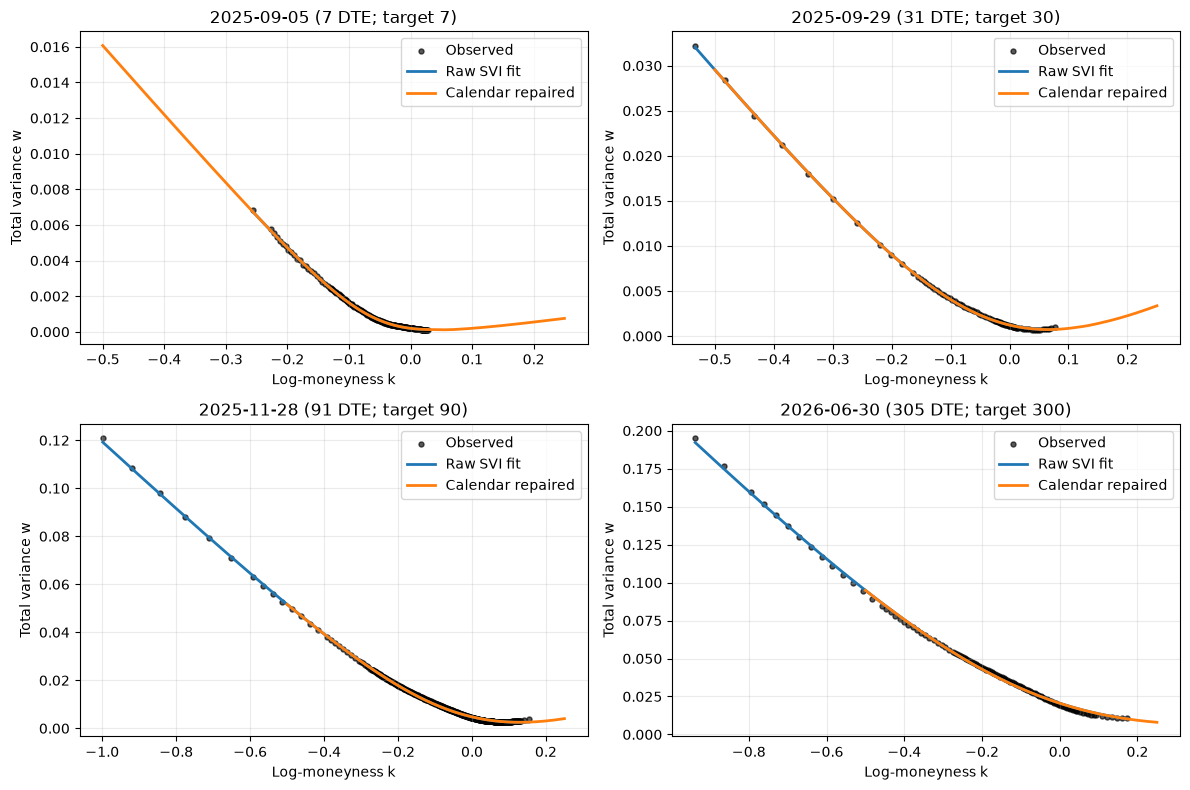

In [3]:
expiry_info = observations[['expiry_date', 'days_to_expiry']].drop_duplicates().sort_values('days_to_expiry')
selected_expiries = []
for target in [7, 30, 90, 300]:
    selected = expiry_info.iloc[(expiry_info['days_to_expiry'] - target).abs().argmin()]
    if selected['expiry_date'] not in [row['expiry_date'] for row in selected_expiries]:
        selected_expiries.append({'target_dte': target, **selected.to_dict()})

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
for ax, selected in zip(axes.flat, selected_expiries):
    expiry = selected['expiry_date']
    rows = observations.loc[observations['expiry_date'].eq(expiry)]
    params = parameters.loc[parameters['expiry_date'].eq(expiry)].iloc[0]
    k_grid = np.linspace(rows['log_moneyness'].min(), rows['log_moneyness'].max(), 400)
    p = [params[name] for name in ['a', 'b', 'rho', 'm', 'sigma']]
    ax.scatter(rows['log_moneyness'], rows['market_w'], s=13, color='black', alpha=0.65, label='Observed')
    ax.plot(k_grid, raw_svi_total_variance(k_grid, *p), color='tab:blue', lw=2, label='Raw SVI fit')
    expiry_index = np.flatnonzero(np.isclose(surface_grid['time_to_expiry'], params['time_to_expiry']))[0]
    ax.plot(calendar_k_grid, surface_grid['repaired_total_variance'][expiry_index], color='tab:orange', lw=2, label='Calendar repaired')
    ax.set(title=f'{expiry.date()} ({selected["days_to_expiry"]} DTE; target {selected["target_dte"]})', xlabel='Log-moneyness k', ylabel='Total variance w')
    ax.grid(alpha=0.25)
    ax.legend()
for ax in axes.flat[len(selected_expiries):]:
    ax.set_visible(False)
fig.tight_layout()
plt.show()

## Observed and fitted 3D total-variance surface

Rotate the figure to inspect observed quotes, the fitted Raw SVI slices, and their calendar-repaired total-variance grid. The Raw SVI mesh is evaluated only within each expiry's observed $k$ range. The repaired mesh uses the common $k\in[-0.5,0.25]$ range.

In [4]:
k_mesh_grid = np.linspace(observations['log_moneyness'].min(), observations['log_moneyness'].max(), 180)
expiry_days = fit_summary['days_to_expiry'].to_numpy()
w_mesh = np.full((len(fit_summary), len(k_mesh_grid)), np.nan)
for i, params in fit_summary.iterrows():
    inside = (k_mesh_grid >= params['k_min']) & (k_mesh_grid <= params['k_max'])
    p = [params[name] for name in ['a', 'b', 'rho', 'm', 'sigma']]
    w_mesh[i, inside] = raw_svi_total_variance(k_mesh_grid[inside], *p)

fig = go.Figure()
fig.add_trace(go.Surface(
    x=k_mesh_grid, y=expiry_days, z=w_mesh, colorscale='Viridis', opacity=0.68,
    connectgaps=False, name='Fitted Raw SVI', colorbar=dict(title='Fitted w'),
))
fig.add_trace(go.Surface(
    x=surface_grid['log_moneyness'],
    y=surface_grid['time_to_expiry'] * 365,
    z=surface_grid['repaired_total_variance'],
    colorscale='Cividis', opacity=0.48, showscale=False, name='Calendar repaired',
))
fig.add_trace(go.Scatter3d(
    x=observations['log_moneyness'], y=observations['days_to_expiry'], z=observations['market_w'],
    mode='markers', marker=dict(size=2, color='black', opacity=0.6), name='Observed w',
    customdata=np.column_stack([observations['fitted_w'], observations['residual_w']]),
    hovertemplate='k=%{x:.3f}<br>DTE=%{y:.0f}<br>Observed w=%{z:.5f}<br>Fitted w=%{customdata[0]:.5f}<br>Residual=%{customdata[1]:+.5f}<extra></extra>',
))
fig.update_layout(title='Observed quotes and fitted Raw SVI slices', width=1000, height=750, scene=dict(xaxis_title='Log-moneyness k', yaxis_title='Days to expiry', zaxis_title='Total variance w'))
fig.show()

## Residual diagnostics

Residuals are fitted minus observed total variance. Look for systematic patterns with moneyness, maturity, or fitted level; a low aggregate RMSE can conceal structured errors. The second plot expresses errors in IV points for easier market interpretation.

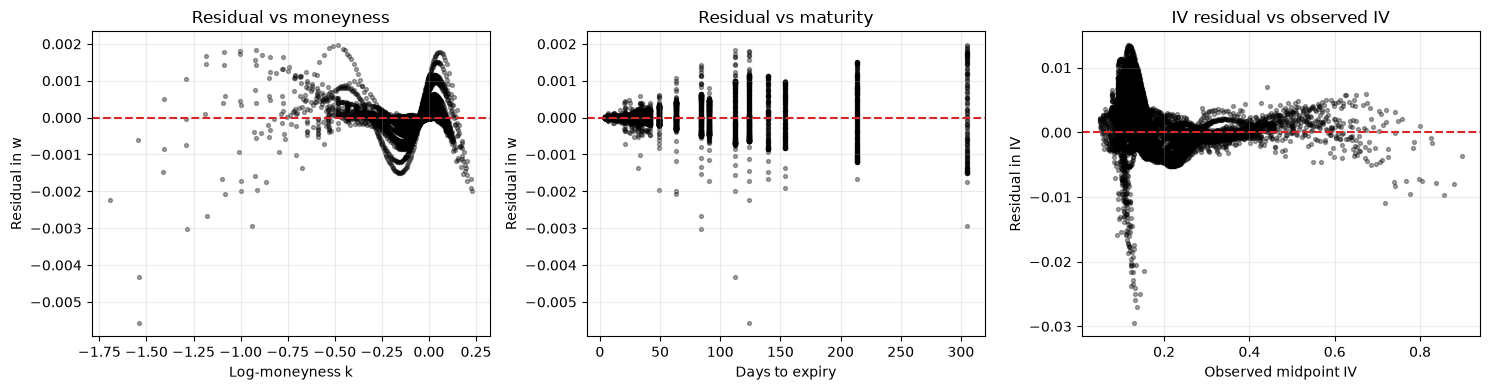

,residual_w,iv_residual
count,6550.000000,6550.000000
mean,0.000017,0.000625
std,0.000386,0.004433
min,-0.005560,-0.029424
25%,-0.000071,-0.002115
50%,0.000000,0.000007
75%,0.000088,0.002660
max,0.001964,0.013477


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(observations['log_moneyness'], observations['residual_w'], s=8, alpha=0.35, color='black')
axes[0].axhline(0, color='tab:red', ls='--')
axes[0].set(xlabel='Log-moneyness k', ylabel='Residual in w', title='Residual vs moneyness')
axes[1].scatter(observations['days_to_expiry'], observations['residual_w'], s=8, alpha=0.35, color='black')
axes[1].axhline(0, color='tab:red', ls='--')
axes[1].set(xlabel='Days to expiry', ylabel='Residual in w', title='Residual vs maturity')
axes[2].scatter(observations['mid_iv'], observations['iv_residual'], s=8, alpha=0.35, color='black')
axes[2].axhline(0, color='tab:red', ls='--')
axes[2].set(xlabel='Observed midpoint IV', ylabel='Residual in IV', title='IV residual vs observed IV')
for ax in axes: ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()
display(observations[['residual_w', 'iv_residual']].describe().round(6))

## Held-out-strike validation

Within each expiry, sort by $k$ and hold out every fifth quote. Fit on the remaining quotes and evaluate the withheld strikes. This tests interpolation across the observed smile; it does not test maturity extrapolation. Compare train and test RMSE per expiry to spot overfitting.

In [6]:
holdout_rows = []
for expiry, rows in observations.groupby('expiry_date', sort=True):
    rows = rows.sort_values('log_moneyness').reset_index(drop=True)
    test_mask = np.arange(len(rows)) % 5 == 0
    train, test = rows.loc[~test_mask].copy(), rows.loc[test_mask].copy()
    fitted = fit_raw_svi_surface(train, enforce_arbitrage=True)['parameters_by_expiry'].iloc[0]
    p = [fitted[name] for name in ['a', 'b', 'rho', 'm', 'sigma']]
    test_w = raw_svi_total_variance(test['log_moneyness'].to_numpy(), *p)
    holdout_rows.append({
        'expiry_date': expiry, 'n_train': len(train), 'n_test': len(test),
        'train_rmse_w': fitted['rmse'],
        'test_rmse_w': float(np.sqrt(np.mean((test_w - test['market_w'].to_numpy()) ** 2))),
    })
holdout = pd.DataFrame(holdout_rows)
display(holdout.assign(expiry_date=holdout['expiry_date'].dt.strftime('%Y-%m-%d')).round(7))
display(holdout[['train_rmse_w', 'test_rmse_w']].describe().round(7))

,expiry_date,n_train,n_test,train_rmse_w,test_rmse_w
0,2025-09-02,89,23,0.000006,0.000006
1,2025-09-03,100,26,0.000005,0.000010
2,2025-09-04,106,27,0.000012,0.000016
3,2025-09-05,150,38,0.000023,0.000031
4,2025-09-08,110,28,0.000016,0.000030
5,2025-09-09,111,28,0.000013,0.000077
6,2025-09-10,112,29,0.000018,0.000095
7,2025-09-11,112,28,0.000017,0.000023
8,2025-09-12,148,37,0.000025,0.000023
9,2025-09-15,99,25,0.000020,0.000126


,train_rmse_w,test_rmse_w
count,38.000000,38.000000
mean,0.000207,0.000286
std,0.000282,0.000326
min,0.000005,0.000006
25%,0.000027,0.000081
50%,0.000087,0.000161
75%,0.000192,0.000390
max,0.001178,0.001380


## Calibration stability

Refit representative expiries from deliberately different starting parameters. Compare both parameter estimates and the fitted curve over the observed strike range. Parameters can vary while the fitted curves remain close, indicating weak parameter identification rather than materially different fits.

In [7]:
stability_rows = []
for selected in selected_expiries:
    expiry = selected['expiry_date']
    rows = observations.loc[observations['expiry_date'].eq(expiry)]
    k = rows['log_moneyness'].to_numpy()
    grid = np.linspace(k.min(), k.max(), 300)
    min_w = float(rows['market_w'].min())
    starts = {
        'default': None,
        'negative_skew': [max(min_w - 0.01, -1.0), 0.03, -0.8, 0.0, 0.05],
        'symmetric': [max(min_w - 0.01, -1.0), 0.15, 0.0, 0.0, 0.2],
        'positive_skew': [max(min_w - 0.01, -1.0), 0.3, 0.7, 0.0, 0.35],
    }
    reference = None
    for name, start in starts.items():
        try:
            params = fit_raw_svi_surface(rows, initial_guess=start, enforce_arbitrage=True)['parameters_by_expiry'].iloc[0]
            p = [params[col] for col in ['a', 'b', 'rho', 'm', 'sigma']]
            curve = raw_svi_total_variance(grid, *p)
            if reference is None: reference = curve
            stability_rows.append({
                'expiry_date': expiry, 'start': name, 'rmse_w': params['rmse'],
                'max_abs_curve_difference': float(np.max(np.abs(curve - reference))),
                **dict(zip(['a', 'b', 'rho', 'm', 'sigma'], p)),
            })
        except ValueError as error:
            stability_rows.append({'expiry_date': expiry, 'start': name, 'error': str(error)})
stability = pd.DataFrame(stability_rows)
display(stability.assign(expiry_date=stability['expiry_date'].dt.strftime('%Y-%m-%d')).round(6))

,expiry_date,start,rmse_w,max_abs_curve_difference,a,b,rho,m,sigma
0,2025-09-05,default,0.000024,0.000000,-0.001865,0.024203,-0.638365,-0.055407,0.106942
1,2025-09-05,negative_skew,0.000024,0.000000,-0.001866,0.024204,-0.638354,-0.055407,0.106944
2,2025-09-05,symmetric,0.000024,0.000000,-0.001866,0.024204,-0.638355,-0.055407,0.106944
3,2025-09-05,positive_skew,0.000024,0.000000,-0.001865,0.024203,-0.638369,-0.055407,0.106941
4,2025-09-29,default,0.000090,0.000000,-0.011729,0.058853,-0.357767,-0.020930,0.226514
5,2025-09-29,negative_skew,0.000090,0.000000,-0.011729,0.058853,-0.357767,-0.020930,0.226514
6,2025-09-29,symmetric,0.000090,0.000000,-0.011729,0.058853,-0.357767,-0.020930,0.226514
7,2025-09-29,positive_skew,0.000090,0.000000,-0.011729,0.058852,-0.357796,-0.020935,0.226514
8,2025-11-28,default,0.000345,0.000000,-0.030610,0.105164,-0.390122,-0.015524,0.342032
9,2025-11-28,negative_skew,0.000345,0.000000,-0.030611,0.105168,-0.390076,-0.015514,0.342031


## Butterfly diagnostics

For each expiry, evaluate total-variance positivity, Durrleman's $g(k)$ on the quoted interval and on the wider $[-5,5]$ grid, plus both wing constraints $b(1+\rho)<2$ and $b(1-\rho)<2$. A violation only on the wide grid is an extrapolation warning; a violation within quoted strikes is more directly relevant. Grid checks are not a formal proof over all real $k$.

In [8]:
butterfly_rows = []
wide_grid = np.linspace(-5.0, 5.0, 4001)
for _, params in parameters.iterrows():
    rows = observations.loc[observations['expiry_date'].eq(params['expiry_date'])]
    p = [params[name] for name in ['a', 'b', 'rho', 'm', 'sigma']]
    quoted_grid = np.linspace(rows['log_moneyness'].min(), rows['log_moneyness'].max(), 1001)
    quoted = raw_svi_butterfly_diagnostic(*p, quoted_grid)
    wide = raw_svi_butterfly_diagnostic(*p, wide_grid)
    butterfly_rows.append({
        'expiry_date': params['expiry_date'], 'k_min': quoted_grid.min(), 'k_max': quoted_grid.max(),
        'min_g_quoted': quoted['minimum_g_on_grid'], 'min_g_wide': wide['minimum_g_on_grid'],
        'g_nonnegative_quoted': quoted['g_nonnegative_on_grid'],
        'g_nonnegative_wide': wide['g_nonnegative_on_grid'],
        'variance_nonnegative': wide['nonnegative_total_variance'],
        'left_wing_slope': wide['left_wing_slope'], 'left_wing_pass': wide['left_wing_condition'],
        'right_wing_slope': wide['right_wing_slope'], 'right_wing_pass': wide['right_wing_condition'],
    })
butterfly = pd.DataFrame(butterfly_rows)
display(butterfly.assign(expiry_date=butterfly['expiry_date'].dt.strftime('%Y-%m-%d')).round(7))
display(butterfly[['g_nonnegative_quoted', 'g_nonnegative_wide', 'variance_nonnegative', 'left_wing_pass', 'right_wing_pass']].mean())

,expiry_date,k_min,k_max,min_g_quoted,min_g_wide,g_nonnegative_quoted,g_nonnegative_wide,variance_nonnegative,left_wing_slope,left_wing_pass,right_wing_slope,right_wing_pass
0,2025-09-02,-0.094889,0.012343,2.790000e-05,4.930000e-05,True,True,True,0.017581,True,0.003724,True
1,2025-09-03,-0.160975,0.016029,1.000000e-07,1.500000e-06,True,True,True,0.025476,True,0.004361,True
2,2025-09-04,-0.179335,0.019820,4.458900e-03,4.460300e-03,True,True,True,0.030312,True,0.004343,True
3,2025-09-05,-0.256562,0.027864,1.714780e-02,1.715680e-02,True,True,True,0.039654,True,0.008753,True
4,2025-09-08,-0.236873,0.028503,2.010980e-02,3.587300e-03,True,True,True,0.038556,True,0.002508,True
5,2025-09-09,-0.297553,0.032201,2.182380e-02,1.736850e-02,True,True,True,0.046463,True,0.006560,True
6,2025-09-10,-0.340247,0.035804,3.212930e-02,3.717900e-03,True,True,True,0.053913,True,0.016163,True
7,2025-09-11,-0.297809,0.043117,3.130510e-02,3.081200e-03,True,True,True,0.052059,True,0.004982,True
8,2025-09-12,-0.385134,0.047239,3.951860e-02,3.257230e-02,True,True,True,0.053958,True,0.008299,True
9,2025-09-15,-0.431620,0.042838,4.821090e-02,2.769000e-03,True,True,True,0.060658,True,0.016528,True


g_nonnegative_quoted    1.0
g_nonnegative_wide      1.0
variance_nonnegative    1.0
left_wing_pass          1.0
right_wing_pass         1.0
dtype: float64

## Calendar diagnostics

Project each fixed-$k$ maturity sequence to its nearest nondecreasing sequence using equal-weight isotonic regression (PAVA). Raw SVI slices are left unchanged; this is a separate surface layer evaluated on the common $k\in[-0.5,0.25]$ grid. Compare calendar crossings before and after projection, quantify total-variance and IV adjustments both within each expiry's quoted $k$ range and outside it, and list adjacent maturities affected. The per-expiry butterfly constraints do not enforce calendar consistency.

After projection, interpolate total variance linearly across maturities and log-moneyness. No extrapolation beyond the fitted grid is allowed.

In [9]:
raw_w = surface_grid['raw_total_variance']
repaired_w = surface_grid['repaired_total_variance']
adjustment_w = repaired_w - raw_w
maturities = surface_grid['time_to_expiry']
raw_iv = np.sqrt(raw_w / maturities[:, None])
repaired_iv = np.sqrt(repaired_w / maturities[:, None])
adjustment_iv_points = 100 * (repaired_iv - raw_iv)
ordered_fit_summary = fit_summary.sort_values('days_to_expiry').reset_index(drop=True)
quote_coverage = np.vstack([
    (calendar_k_grid >= row['k_min']) & (calendar_k_grid <= row['k_max'])
    for _, row in ordered_fit_summary.iterrows()
])
quoted_adjustment_w = np.where(quote_coverage, adjustment_w, np.nan)
quoted_adjustment_iv = np.where(quote_coverage, adjustment_iv_points, np.nan)
raw_calendar_difference = np.diff(raw_w, axis=0)
repaired_calendar_difference = np.diff(repaired_w, axis=0)

calendar_rows = []
for i in range(len(maturities) - 1):
    near = ordered_fit_summary.iloc[i]
    far = ordered_fit_summary.iloc[i + 1]
    overlap = (calendar_k_grid >= max(near['k_min'], far['k_min'])) & (
        calendar_k_grid <= min(near['k_max'], far['k_max'])
    )
    raw_overlap = raw_calendar_difference[i, overlap]
    repaired_overlap = repaired_calendar_difference[i, overlap]
    changed_in_overlap = bool(np.any(np.abs(adjustment_w[i:i + 2, overlap]) > 1e-12)) if overlap.any() else False
    calendar_rows.append({
        'near_expiry': near['expiry_date'], 'near_dte': near['days_to_expiry'],
        'far_expiry': far['expiry_date'], 'far_dte': far['days_to_expiry'],
        'raw_crossings_in_quote_overlap': int((raw_overlap < -1e-10).sum()),
        'repaired_crossings_in_quote_overlap': int((repaired_overlap < -1e-10).sum()),
        'raw_crossings_on_full_grid': int((raw_calendar_difference[i] < -1e-10).sum()),
        'repaired_crossings_on_full_grid': int((repaired_calendar_difference[i] < -1e-10).sum()),
        'repair_changed_pair': bool(np.any(np.abs(adjustment_w[i:i + 2]) > 1e-12)),
        'repair_changed_pair_in_quote_overlap': changed_in_overlap,
    })
calendar = pd.DataFrame(calendar_rows)
display(calendar.assign(near_expiry=calendar['near_expiry'].dt.strftime('%Y-%m-%d'), far_expiry=calendar['far_expiry'].dt.strftime('%Y-%m-%d')))

adjustment_summary = pd.Series({
    'max_abs_adjustment_w': np.abs(adjustment_w).max(),
    'max_abs_adjustment_w_in_quotes': np.nanmax(np.abs(quoted_adjustment_w)),
    'median_abs_adjustment_w': np.median(np.abs(adjustment_w)),
    'median_abs_adjustment_w_in_quotes': np.nanmedian(np.abs(quoted_adjustment_w)),
    'median_nonzero_abs_adjustment_w': np.median(np.abs(adjustment_w)[np.abs(adjustment_w) > 1e-12]),
    'max_abs_adjustment_iv_points': np.abs(adjustment_iv_points).max(),
    'max_abs_adjustment_iv_points_in_quotes': np.nanmax(np.abs(quoted_adjustment_iv)),
    'median_abs_adjustment_iv_points': np.median(np.abs(adjustment_iv_points)),
    'median_abs_adjustment_iv_points_in_quotes': np.nanmedian(np.abs(quoted_adjustment_iv)),
    'raw_crossings_in_quote_overlap': calendar['raw_crossings_in_quote_overlap'].sum(),
    'repaired_crossings_in_quote_overlap': calendar['repaired_crossings_in_quote_overlap'].sum(),
    'raw_crossings_on_full_grid': calendar['raw_crossings_on_full_grid'].sum(),
    'repaired_crossings_on_full_grid': calendar['repaired_crossings_on_full_grid'].sum(),
    'adjacent_pairs_changed': calendar['repair_changed_pair'].sum(),
    'adjacent_pairs_changed_in_quote_overlap': calendar['repair_changed_pair_in_quote_overlap'].sum(),
})
display(adjustment_summary.to_frame('value').round(8))
maturity_adjustments = []
for i, params in parameters.sort_values('time_to_expiry').reset_index(drop=True).iterrows():
    max_iv_column = int(np.abs(adjustment_iv_points[i]).argmax())
    maturity_adjustments.append({
        'expiry_date': params['expiry_date'],
        'max_abs_adjustment_w': np.abs(adjustment_w[i]).max(),
        'max_abs_adjustment_w_in_quotes': np.nanmax(np.abs(quoted_adjustment_w[i])),
        'median_abs_adjustment_w': np.median(np.abs(adjustment_w[i])),
        'max_abs_adjustment_iv_points': np.abs(adjustment_iv_points[i]).max(),
        'max_abs_adjustment_iv_points_in_quotes': np.nanmax(np.abs(quoted_adjustment_iv[i])),
        'k_at_max_iv_adjustment': calendar_k_grid[max_iv_column],
    })
maturity_adjustments = pd.DataFrame(maturity_adjustments)
display(maturity_adjustments.assign(expiry_date=maturity_adjustments['expiry_date'].dt.strftime('%Y-%m-%d')).round(7))
display(calendar.loc[calendar['repair_changed_pair_in_quote_overlap'], ['near_expiry', 'far_expiry', 'raw_crossings_in_quote_overlap', 'repair_changed_pair_in_quote_overlap']])

target_smiles = []
for target_dte in [30, 60, 90]:
    evaluated = evaluate_surface(calendar_k_grid, target_dte / 365, surface_grid)
    target_smiles.append(pd.DataFrame({
        'target_dte': target_dte, 'log_moneyness': calendar_k_grid,
        'total_variance': evaluated['total_variance'],
        'implied_volatility': evaluated['implied_volatility'],
    }))
interpolated_smiles = pd.concat(target_smiles, ignore_index=True)
display(interpolated_smiles.groupby('target_dte')[['implied_volatility']].agg(['min', 'median', 'max']).round(6))

,near_expiry,near_dte,far_expiry,far_dte,raw_crossings_in_quote_overlap,repaired_crossings_in_quote_overlap,raw_crossings_on_full_grid,repaired_crossings_on_full_grid,repair_changed_pair,repair_changed_pair_in_quote_overlap
0,2025-09-02,4,2025-09-03,5,0,0,31,0,True,False
1,2025-09-03,5,2025-09-04,6,0,0,42,0,True,False
2,2025-09-04,6,2025-09-05,7,0,0,0,0,True,False
3,2025-09-05,7,2025-09-08,10,0,0,44,0,True,False
4,2025-09-08,10,2025-09-09,11,0,0,0,0,True,False
5,2025-09-09,11,2025-09-10,12,0,0,0,0,True,False
6,2025-09-10,12,2025-09-11,13,0,0,41,0,True,False
7,2025-09-11,13,2025-09-12,14,0,0,0,0,True,False
8,2025-09-12,14,2025-09-15,17,0,0,0,0,True,False
9,2025-09-15,17,2025-09-16,18,0,0,0,0,True,False


,value
max_abs_adjustment_w,0.000785
max_abs_adjustment_w_in_quotes,0.000129
median_abs_adjustment_w,0.000000
median_abs_adjustment_w_in_quotes,0.000000
median_nonzero_abs_adjustment_w,0.000056
max_abs_adjustment_iv_points,7.033983
max_abs_adjustment_iv_points_in_quotes,0.899906
median_abs_adjustment_iv_points,0.000000
median_abs_adjustment_iv_points_in_quotes,0.000000
raw_crossings_in_quote_overlap,20.000000


,expiry_date,max_abs_adjustment_w,max_abs_adjustment_w_in_quotes,median_abs_adjustment_w,max_abs_adjustment_iv_points,max_abs_adjustment_iv_points_in_quotes,k_at_max_iv_adjustment
0,2025-09-02,5.310000e-05,0.000000e+00,0.0,1.454390,0.000000,0.115
1,2025-09-03,4.370000e-05,0.000000e+00,0.0,0.894241,0.000000,0.150
2,2025-09-04,3.940000e-05,0.000000e+00,0.0,0.660231,0.000000,0.070
3,2025-09-05,4.942000e-04,0.000000e+00,0.0,5.685277,0.000000,0.250
4,2025-09-08,5.036000e-04,0.000000e+00,0.0,7.033983,0.000000,0.250
5,2025-09-09,3.250000e-05,0.000000e+00,0.0,0.550424,0.000000,0.130
6,2025-09-10,7.566000e-04,0.000000e+00,0.0,5.500439,0.000000,0.250
7,2025-09-11,6.295000e-04,0.000000e+00,0.0,6.142790,0.000000,0.250
8,2025-09-12,1.272000e-04,0.000000e+00,0.0,1.016039,0.000000,0.250
9,2025-09-15,0.000000e+00,0.000000e+00,0.0,0.000000,0.000000,-0.500


,near_expiry,far_expiry,raw_crossings_in_quote_overlap,repair_changed_pair_in_quote_overlap
12,2025-09-18,2025-09-19,0,True
13,2025-09-19,2025-09-22,6,True
14,2025-09-22,2025-09-23,0,True
15,2025-09-23,2025-09-24,0,True
17,2025-09-25,2025-09-26,0,True
18,2025-09-26,2025-09-29,1,True
19,2025-09-29,2025-09-30,0,True
20,2025-09-30,2025-10-01,6,True
21,2025-10-01,2025-10-02,0,True
29,2025-10-31,2025-11-21,0,True


implied_volatility                    
                          min    median       max
target_dte                                       
30                   0.093416  0.248578  0.597936
60                   0.099233  0.226635  0.502603
90                   0.100905  0.216491  0.456414